# Doshisha Logo Detection System

## 1. 課題の目的

## 2. ライブラリの準備

## 3. Google Driveのマウント

## 4. データセットの準備

## 5. Selective Searchによる候補領域の抽出

## 6. CNNモデルの準備

## 7. CNNの学習

## 8. テスト画像での同志社ロゴ検出

## 9. 結果と考察

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os

base_dir = "/content/drive/MyDrive/DoshishaLogoDetection"

positive_dir = os.path.join(base_dir, "data/positive")
negative_dir = os.path.join(base_dir, "data/negative")
test_dir = os.path.join(base_dir, "data/test")
output_dir = os.path.join(base_dir, "outputs")

for d in [positive_dir, negative_dir, test_dir, output_dir]:
  os.makedirs(d, exist_ok=True)

print("Created directories:")
print(positive_dir)
print(negative_dir)
print(test_dir)
print(output_dir)

Created directories:
/content/drive/MyDrive/DoshishaLogoDetection/data/positive
/content/drive/MyDrive/DoshishaLogoDetection/data/negative
/content/drive/MyDrive/DoshishaLogoDetection/data/test
/content/drive/MyDrive/DoshishaLogoDetection/outputs


In [38]:
!pip install -U opencv-contrib-python-headless==4.12.0.88

In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

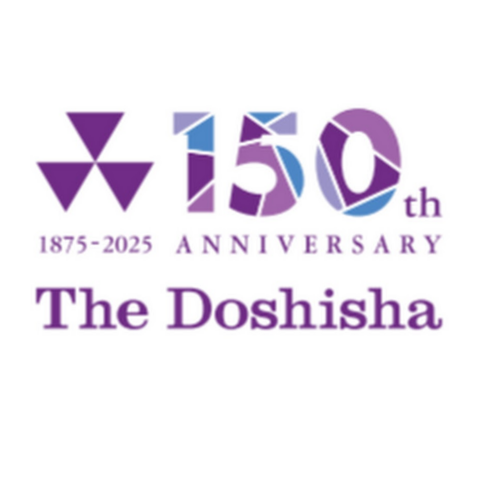

In [40]:
test_image_path = os.path.join(test_dir, "test.jpg")

img = Image.open(test_image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## 5. Selective Searchによる候補領域の抽出

Selective Searchは、画像の中で物体が存在する可能性のある領域を多数生成する手法である。
本課題では、画像全体を直接CNNに入力するのではなく、まずSelective Searchによって候補領域を抽出し、その各領域に対してCNNによる二値分類を行う。

In [41]:
import cv2
import matplotlib.pyplot as plt
import os

test_image_path = os.path.join(test_dir, "test.jpg")
image_bgr = cv2.imread(test_image_path)

if image_bgr is None:
  raise FileNotFoundError(f"画像が読み込めません: {test_image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image_bgr)

ss.switchToSelectiveSearchFast()

rects = ss.process()

print(f"候補領域の数: {len(rects)}")
print("最初の5個: ", rects[:5])

候補領域の数: 1652
最初の5個:  [[796 346  45  58]
 [453 302  81 105]
 [645 281 117 103]
 [309 544  81  75]
 [471 301  49  73]]


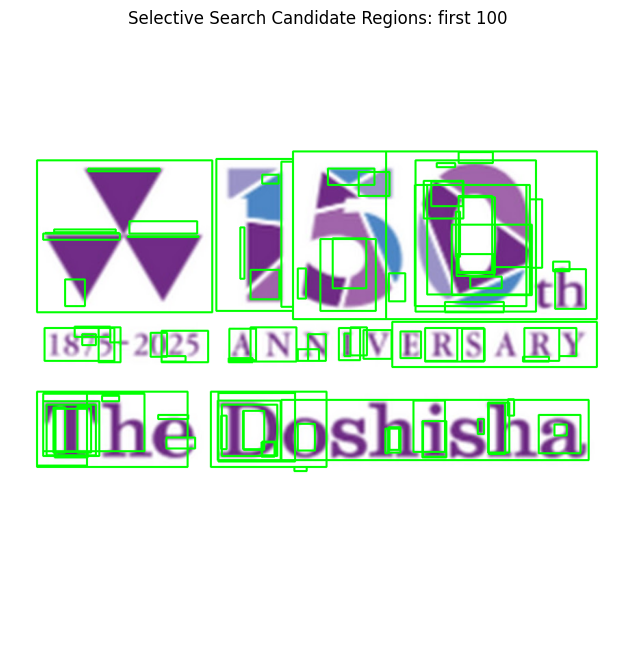

In [42]:
output_image = image_rgb.copy()

max_regions = 100

for (x, y, w, h) in rects[:max_regions]:
  cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(output_image)
plt.axis("off")
plt.title(f"Selective Search Candidate Regions: first {max_regions}")
plt.show()

絞り込み後の候補領域数: 1132
最初の5個: [(np.int32(796), np.int32(346), np.int32(45), np.int32(58)), (np.int32(453), np.int32(302), np.int32(81), np.int32(105)), (np.int32(645), np.int32(281), np.int32(117), np.int32(103)), (np.int32(309), np.int32(544), np.int32(81), np.int32(75)), (np.int32(471), np.int32(301), np.int32(49), np.int32(73))]


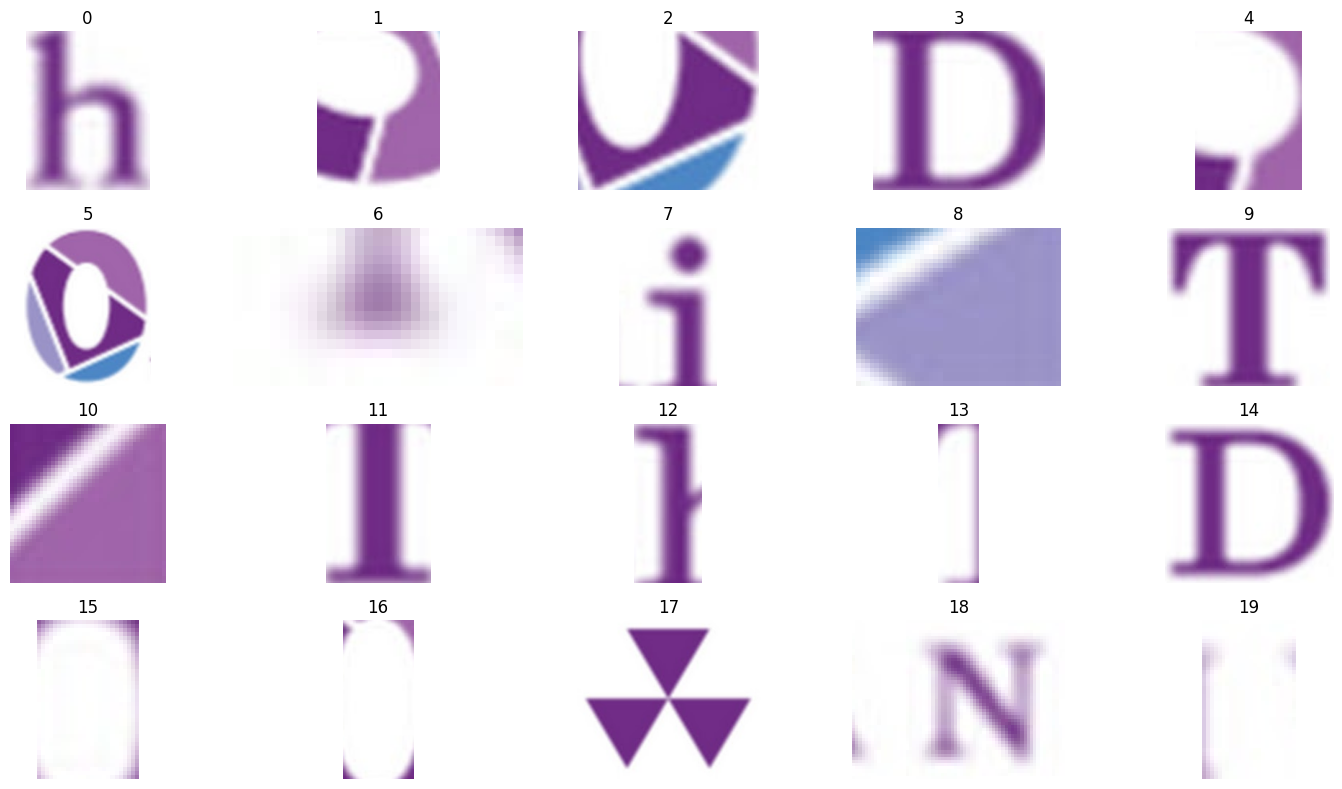

In [43]:
filtered_rects = []

image_h, image_w = image_rgb.shape[:2]

for (x, y, w, h) in rects:
  area = w * h
  aspect_ratio = w / h

  if area < 500:
    continue
  if area > image_w * image_h * 0.5:
    continue
  if aspect_ratio < 0.2 or aspect_ratio > 5.0:
    continue

  filtered_rects.append((x, y, w, h))

print(f"絞り込み後の候補領域数: {len(filtered_rects)}")
print("最初の5個:", filtered_rects[:5])

num_show = 20

plt.figure(figsize=(15, 8))

for i, (x, y, w, h) in enumerate(filtered_rects[:num_show]):
  crop = image_rgb[y:y+h, x:x+w]

  plt.subplot(4, 5, i + 1)
  plt.imshow(crop)
  plt.axis("off")
  plt.title(f"{i}")

plt.tight_layout()
plt.show()


In [44]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

positive_files = [
    f for f in os.listdir(positive_dir)
    if f.lower().endswith(image_extensions)
]

negative_files = [
    f for f in os.listdir(negative_dir)
    if f.lower().endswith(image_extensions)
]

print("positive images:", len(positive_files))
print("negative images:", len(negative_files))

print("positive sample:", positive_files[:5])
print("negative sample:", negative_files[:5])

positive images: 30
negative images: 80
positive sample: ['images (26).jpeg', 'images (1).jpeg', 'images (2).jpeg', 'images (3).jpeg', 'images (4).jpeg']
negative sample: ['negative_0077.jpg', 'negative_0047.jpg', 'negative_0025.jpg', 'negative_0008.jpg', 'negative_0009.jpg']


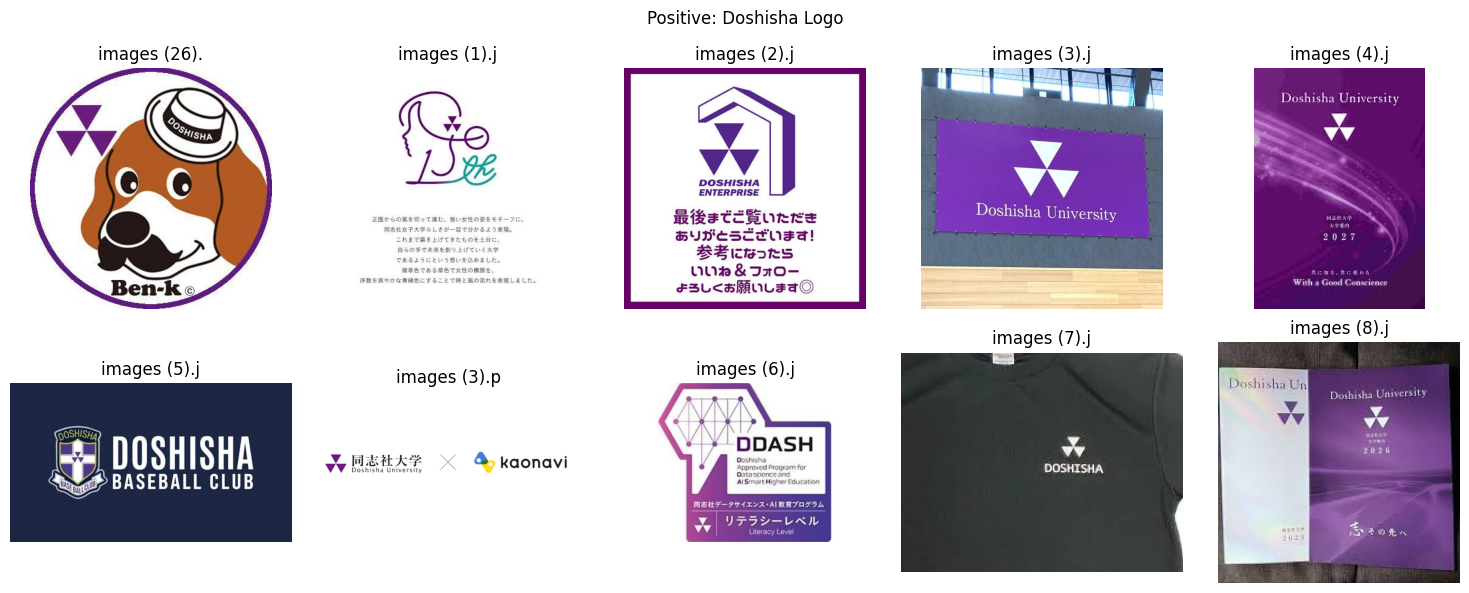

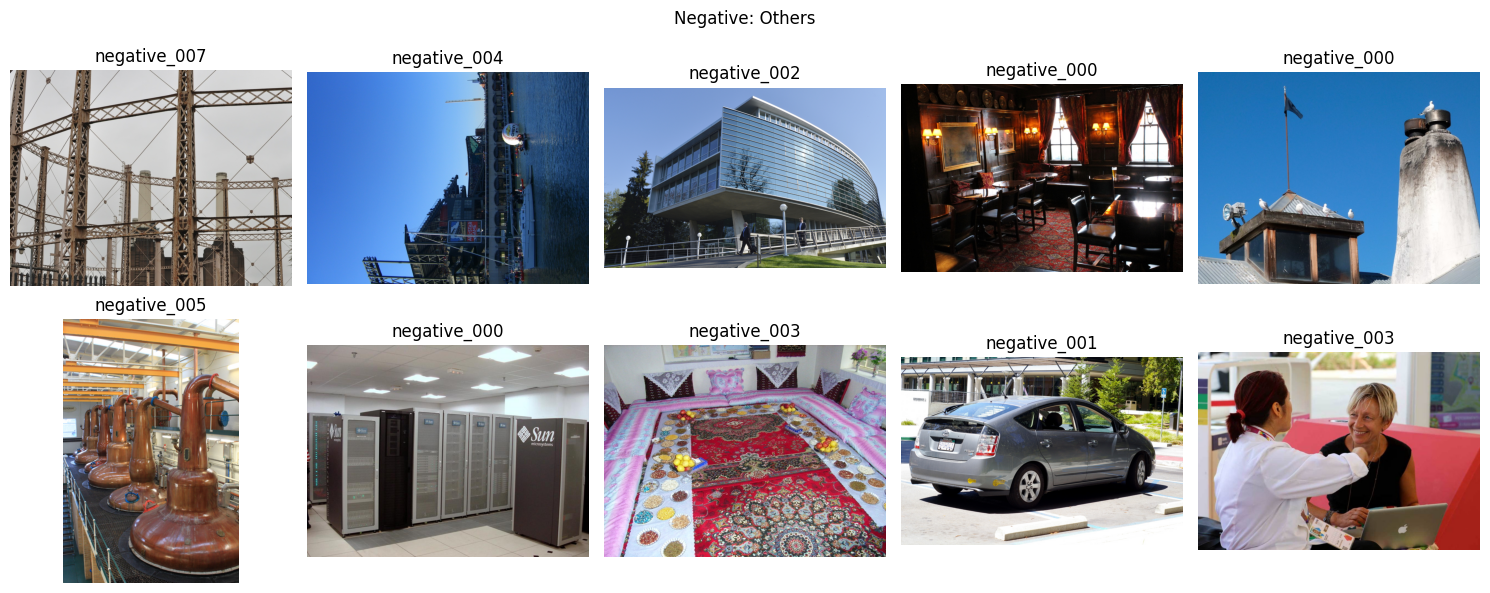

In [45]:
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_images(folder, files, title, num_images=10):
    plt.figure(figsize=(15, 6))

    for i, filename in enumerate(files[:num_images]):
        path = os.path.join(folder, filename)
        img = Image.open(path).convert("RGB")

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(filename[:12])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_images(positive_dir, positive_files, "Positive: Doshisha Logo")
show_sample_images(negative_dir, negative_files, "Negative: Others")

## 6. CNNによる二値分類

本課題では、Selective Searchで抽出した候補領域を「同志社ロゴ」または「その他」に分類するためにCNNを用いる。
CNNは画像の局所的な特徴を抽出できるため、ロゴの形状や色、模様などを利用した分類に適している。
本実装では、事前学習済みのResNet18を利用し、最後の分類層のみを2クラス分類用に変更する。

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [47]:
import os
from PIL import Image
from torch.utils.data import Dataset

class DoshishaLogoDataset(Dataset):
    def __init__(self, positive_dir, negative_dir, transform=None):
        self.samples = []
        self.transform = transform

        image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

        # positive: 同志社ロゴ = 1
        for filename in os.listdir(positive_dir):
            if filename.lower().endswith(image_extensions):
                path = os.path.join(positive_dir, filename)
                self.samples.append((path, 1))

        # negative: その他 = 0
        for filename in os.listdir(negative_dir):
            if filename.lower().endswith(image_extensions):
                path = os.path.join(negative_dir, filename)
                self.samples.append((path, 0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [48]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = DoshishaLogoDataset(
    positive_dir=positive_dir,
    negative_dir=negative_dir,
    transform=transform
)

print("dataset size:", len(dataset))

labels = [label for _, label in dataset.samples]
print("negative:", labels.count(0))
print("positive:", labels.count(1))
print("unique labels:", sorted(set(labels)))

dataset size: 110
negative: 80
positive: 30
unique labels: [0, 1]


In [49]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print("train size:", len(train_dataset))
print("val size:", len(val_dataset))

train size: 88
val size: 22


In [50]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [51]:
num_epochs = 5

for epoch in range(num_epochs):
  model.train()
  train_loss = 0.0
  train_correct = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    train_loss += loss.item() * images.size(0)
    _, preds = torch.max(outputs, 1)
    train_correct += torch.sum(preds == labels).item()

  train_loss = train_loss / len(train_dataset)
  train_acc = train_correct / len(train_dataset)

  model.eval()
  val_loss = 0.0
  val_correct = 0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      val_loss += loss.item() * images.size(0)
      _, preds = torch.max(outputs, 1)
      val_correct += torch.sum(preds == labels).item()

  val_loss = val_loss / len(val_dataset)
  val_acc = val_correct / len(val_dataset)

  print(
      f"Epoch [{epoch+1}/{num_epochs}] "
      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
  )

Epoch [1/5] Train Loss: 0.5822, Train Acc: 0.8182, Val Loss: 14.8732, Val Acc: 0.2727
Epoch [2/5] Train Loss: 0.9139, Train Acc: 0.8409, Val Loss: 22.8116, Val Acc: 0.2727
Epoch [3/5] Train Loss: 0.3808, Train Acc: 0.9091, Val Loss: 6.0001, Val Acc: 0.3636
Epoch [4/5] Train Loss: 0.3374, Train Acc: 0.9205, Val Loss: 1.4628, Val Acc: 0.6364
Epoch [5/5] Train Loss: 0.2031, Train Acc: 0.9545, Val Loss: 0.7969, Val Acc: 0.7727


In [52]:
model_path = os.path.join(base_dir, "doshisha_logo_resnet18.pth")

torch.save(model.state_dict(), model_path)

print("Saved model to:", model_path)

Saved model to: /content/drive/MyDrive/DoshishaLogoDetection/doshisha_logo_resnet18.pth


## 8. テスト画像での同志社ロゴ検出

学習済みCNNを用いて、Selective Searchで抽出した候補領域を「同志社ロゴ」または「その他」に分類する。
各候補領域を切り出してCNNに入力し、同志社ロゴである確率が高い領域を検出結果として画像上に描画する。

In [53]:
import torch.nn.functional as F
from PIL import Image

def predict_region(crop_rgb, model, transform, device):
    """
    切り出した候補領域が同志社ロゴかどうかを判定する関数
    crop_rgb: RGB形式のNumPy画像
    """

    # NumPy配列をPIL画像に変換
    crop_pil = Image.fromarray(crop_rgb).convert("RGB")

    # 学習時と同じ前処理を適用
    input_tensor = transform(crop_pil)

    # バッチ次元を追加: [3, 224, 224] -> [1, 3, 224, 224]
    input_tensor = input_tensor.unsqueeze(0)

    # GPUまたはCPUへ送る
    input_tensor = input_tensor.to(device)

    # 推論
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)

        # 出力スコアを確率に変換
        probs = F.softmax(outputs, dim=1)

        # クラス1 = positive = 同志社ロゴ の確率
        logo_prob = probs[0, 1].item()

        # 予測クラス
        pred_class = torch.argmax(probs, dim=1).item()

    return pred_class, logo_prob

In [54]:
# テスト画像を読み込み直す
test_image_path = os.path.join(test_dir, "test.jpg")

image_bgr = cv2.imread(test_image_path)

if image_bgr is None:
    raise FileNotFoundError(f"画像が読み込めません: {test_image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Selective Searchを実行
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image_bgr)

# FastではなくQualityを使う
ss.switchToSelectiveSearchQuality()

rects = ss.process()

# numpy配列を普通のtupleに変換して扱いやすくする
rects = [(int(x), int(y), int(w), int(h)) for x, y, w, h in rects]

print("候補領域の数:", len(rects))
print("最初の5個:", rects[:5])

候補領域の数: 4847
最初の5個: [(420, 463, 31, 17), (47, 537, 226, 89), (461, 525, 394, 110), (310, 422, 548, 68), (602, 567, 36, 54)]


In [55]:
proposal_rects = rects

print("CNNに渡す候補領域数:", len(proposal_rects))
print("最初の5個:", proposal_rects[:5])

CNNに渡す候補領域数: 4847
最初の5個: [(420, 463, 31, 17), (47, 537, 226, 89), (461, 525, 394, 110), (310, 422, 548, 68), (602, 567, 36, 54)]


In [67]:
detections = []

threshold = 0.80  # まずは低めにして、候補が出るか確認する

for (x, y, w, h) in proposal_rects:
    crop_rgb = image_rgb[y:y+h, x:x+w]

    # 念のため、空画像を除外
    if crop_rgb.size == 0:
        continue

    pred_class, logo_prob = predict_region(
        crop_rgb=crop_rgb,
        model=model,
        transform=transform,
        device=device
    )

    # まずは logo_prob だけで判定する
    if logo_prob >= threshold:
        detections.append((x, y, w, h, logo_prob))

print("検出数:", len(detections))

detections_sorted = sorted(detections, key=lambda x: x[4], reverse=True)

# 重複した検出枠を整理するためにNMSを行う

boxes = []
scores = []

for (x, y, w, h, score) in detections_sorted:
    boxes.append([x, y, w, h])
    scores.append(float(score))

# score_threshold: この値未満の候補は除外
# nms_threshold: 重なりが大きい候補をまとめる強さ
indices = cv2.dnn.NMSBoxes(
    boxes,
    scores,
    score_threshold=0.50,
    nms_threshold=0.30
)

nms_detections = []

if len(indices) > 0:
    for i in np.array(indices).flatten():
        x, y, w, h = boxes[i]
        score = scores[i]
        nms_detections.append((x, y, w, h, score))

print("NMS後の検出数:", len(nms_detections))
print("上位10件:")
for det in nms_detections[:10]:
    print(det)

検出数: 4522
NMS後の検出数: 524
上位10件:
(47, 537, 226, 89, 1.0)
(461, 525, 394, 110, 1.0)
(310, 422, 548, 68, 1.0)
(38, 185, 258, 225, 1.0)
(414, 175, 443, 242, 1.0)
(570, 304, 2, 56, 1.0)
(0, 0, 900, 900, 1.0)
(752, 335, 96, 83, 1.0)
(558, 448, 192, 41, 1.0)
(52, 542, 75, 29, 1.0)


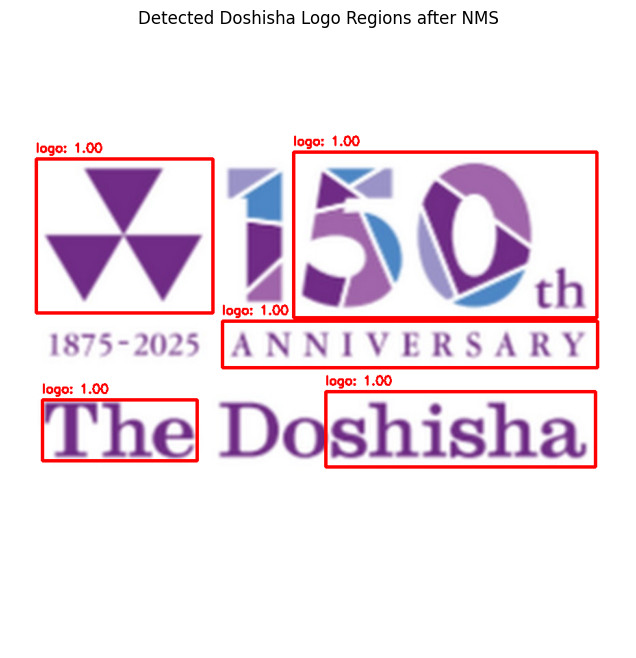

In [71]:
result_image = image_rgb.copy()

for (x, y, w, h, score) in nms_detections[:5]:
    cv2.rectangle(result_image, (x, y), (x + w, y + h), (255, 0, 0), 3)

    label_text = f"logo: {score:.2f}"
    cv2.putText(
        result_image,
        label_text,
        (x, max(y - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(result_image)
plt.axis("off")
plt.title("Detected Doshisha Logo Regions after NMS")
plt.show()

In [72]:
output_path = os.path.join(output_dir, "detection_result.jpg")

# RGBからBGRに戻して保存
result_bgr = cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR)
cv2.imwrite(output_path, result_bgr)

print("Saved detection result to:", output_path)

Saved detection result to: /content/drive/MyDrive/DoshishaLogoDetection/outputs/detection_result.jpg


### 検出結果

Selective Searchによって得られた候補領域を、学習済みCNNで「同志社ロゴ」または「その他」に分類した。
その後、重複する検出枠をNMSによって整理し、ロゴと判定された候補領域を画像上に描画した。

結果として、テスト画像中の同志社ロゴ周辺に検出枠を表示することができた。
一方で、一部の背景領域もロゴとして判定される場合があり、これは学習画像数や負例画像の不足が原因と考えられる。